# Brief 2 - Nettoyage technique et nettoyage ethique

Ce notebook sert de support de correction.
Le projet produit seulement deux sorties :
- `data/cleaned.csv` : dataset nettoye et entierement numerique ;
- `data/ethical_cleaned.csv` : dataset nettoye, reduit ethiquement et entierement numerique.


## 1. Imports

Le notebook importe les fonctions du projet pour rester coherent avec le code Python principal.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "modules").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from modules.analysis import (
    analyse_correlation,
    analyse_missing_values,
    analyse_outliers,
    compare_features,
    plot_distribution,
)
from modules.cleaning import clean_dataset, drop_sensitive_columns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_DIR = ROOT_DIR / "data"
RAW_PATH = DATA_DIR / "raw.csv"
CLEAN_PATH = DATA_DIR / "cleaned.csv"
ETHICAL_PATH = DATA_DIR / "ethical_cleaned.csv"

print("Project root:", ROOT_DIR)
print("Raw path:", RAW_PATH)

Project root: /Users/alexandreadolphe/Developer/up-skilling-ia/m2-brief-2
Raw path: /Users/alexandreadolphe/Developer/up-skilling-ia/m2-brief-2/data/raw.csv


## Execution order

Si une cellule echoue, relance d'abord la cellule d'imports ci-dessus.
Elle configure le chemin du projet pour que le notebook fonctionne aussi bien depuis la racine que depuis le dossier `notebooks`.

## 2. Chargement du dataset brut

On lit le fichier source puis on affiche sa structure generale.

In [2]:
raw_df = pd.read_csv(RAW_PATH)

print("Shape:", raw_df.shape)
print()
print(raw_df.dtypes)
print()
raw_df.head()

Shape: (10000, 19)

nom                          str
prenom                       str
age                        int64
taille                   float64
poids                    float64
sexe                         str
sport_licence                str
niveau_etude                 str
region                       str
smoker                       str
nationalité_francaise        str
revenu_estime_mois         int64
situation_familiale          str
historique_credits       float64
risque_personnel         float64
date_creation_compte         str
score_credit             float64
loyer_mensuel            float64
montant_pret             float64
dtype: object



,nom,prenom,age,taille,poids,sexe,sport_licence,niveau_etude,region,smoker,nationalité_francaise,revenu_estime_mois,situation_familiale,historique_credits,risque_personnel,date_creation_compte,score_credit,loyer_mensuel,montant_pret
0,Ramirez,Casey,73,161.1,67.3,H,non,master,Occitanie,non,oui,857,célibataire,NaN,0.11,2024-09-28,615.0,1377.97,13157.101646
1,Hill,Phillip,44,168.2,74.9,H,non,bac,Île-de-France,non,oui,5245,célibataire,2.0,0.79,2023-06-26,NaN,10000.00,32408.309272
2,Hernandez,Martin,71,160.3,45.5,H,non,doctorat,Auvergne-Rhône-Alpes,oui,oui,3792,célibataire,0.0,0.13,2023-06-13,NaN,5000.00,17975.461375
3,Miller,Michael,62,161.9,87.7,F,oui,bac,Auvergne-Rhône-Alpes,oui,oui,3291,divorcé,NaN,0.32,2024-01-12,NaN,10000.00,16004.737731
4,Walker,Matthew,18,178.0,77.6,F,oui,bac,Corse,non,oui,3893,célibataire,NaN,0.66,2023-02-16,NaN,NaN,10437.682760


## 3. Diagnostic rapide de la qualite des donnees

On combine ici un diagnostic chiffre et les visualisations du module `modules/analysis.py`.

In [3]:
missing_by_col = (raw_df.isna().mean().sort_values(ascending=False) * 100).round(2)
rows_with_nan = int(raw_df.isna().any(axis=1).sum())

print("Valeurs manquantes (%) par colonne :")
print(missing_by_col)
print()
print("Nombre de lignes avec au moins un NaN :", rows_with_nan)
print()
print("Loyers negatifs :", int((pd.to_numeric(raw_df["loyer_mensuel"], errors="coerce") < 0).sum()))
print("Montants de pret negatifs :", int((pd.to_numeric(raw_df["montant_pret"], errors="coerce") < 0).sum()))
print("Revenus negatifs :", int((pd.to_numeric(raw_df["revenu_estime_mois"], errors="coerce") < 0).sum()))

Valeurs manquantes (%) par colonne :
score_credit             53.06
historique_credits       52.93
loyer_mensuel            29.06
situation_familiale      23.52
nom                       0.00
nationalité_francaise     0.00
date_creation_compte      0.00
risque_personnel          0.00
revenu_estime_mois        0.00
smoker                    0.00
prenom                    0.00
region                    0.00
niveau_etude              0.00
sport_licence             0.00
sexe                      0.00
poids                     0.00
taille                    0.00
age                       0.00
montant_pret              0.00
dtype: float64

Nombre de lignes avec au moins un NaN : 8802

Loyers negatifs : 16
Montants de pret negatifs : 0
Revenus negatifs : 0


### 3.1 Analyse des valeurs manquantes

missing values :
 nom                         0
prenom                      0
age                         0
taille                      0
poids                       0
sexe                        0
sport_licence               0
niveau_etude                0
region                      0
smoker                      0
nationalité_francaise       0
revenu_estime_mois          0
situation_familiale      2352
historique_credits       5293
risque_personnel            0
date_creation_compte        0
score_credit             5306
loyer_mensuel            2906
montant_pret                0
dtype: int64

columns > 50% NaN :
 score_credit          53.06
historique_credits    52.93
dtype: float64

columns > 80% NaN :
 Series([], dtype: float64)
percentage of missing values by column :
 score_credit             53.06
historique_credits       52.93
loyer_mensuel            29.06
situation_familiale      23.52
nom                       0.00
nationalité_francaise     0.00
date_creation_compte      0.0

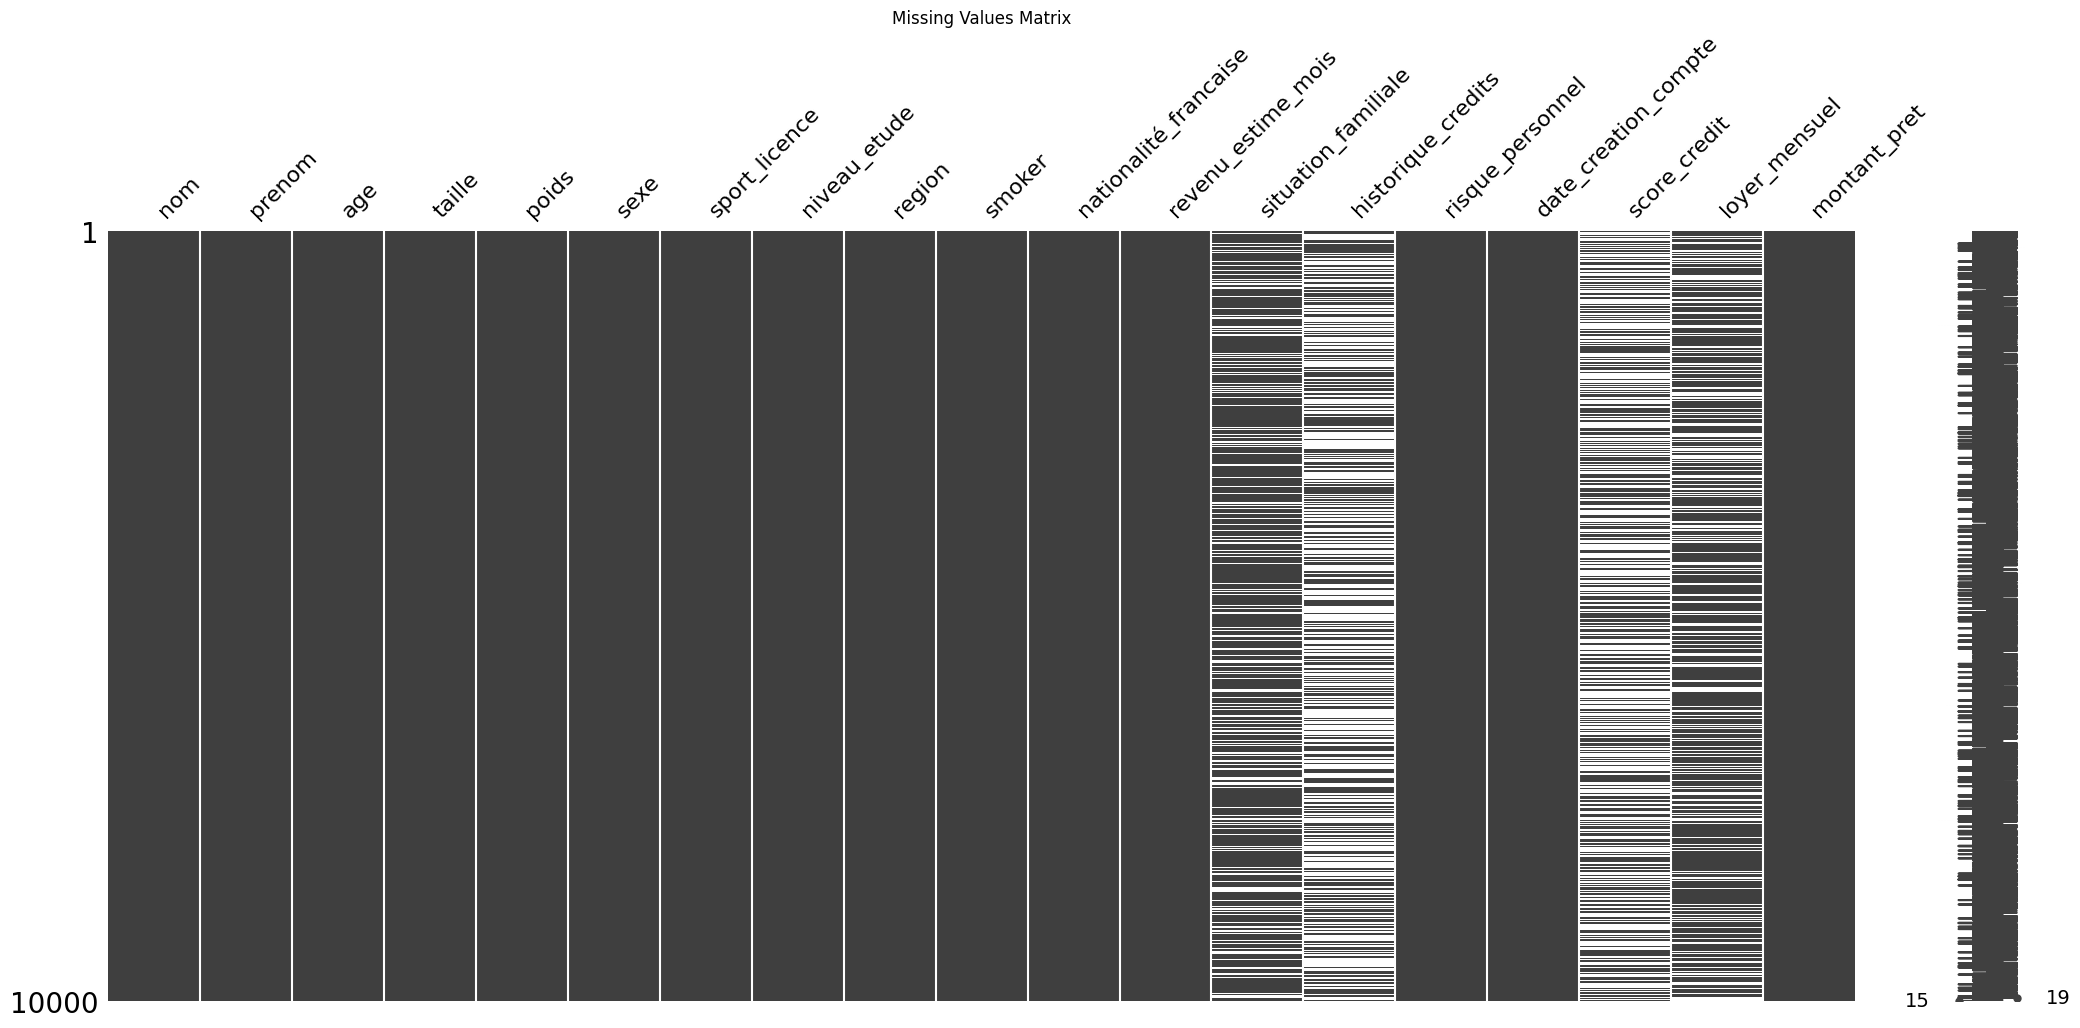

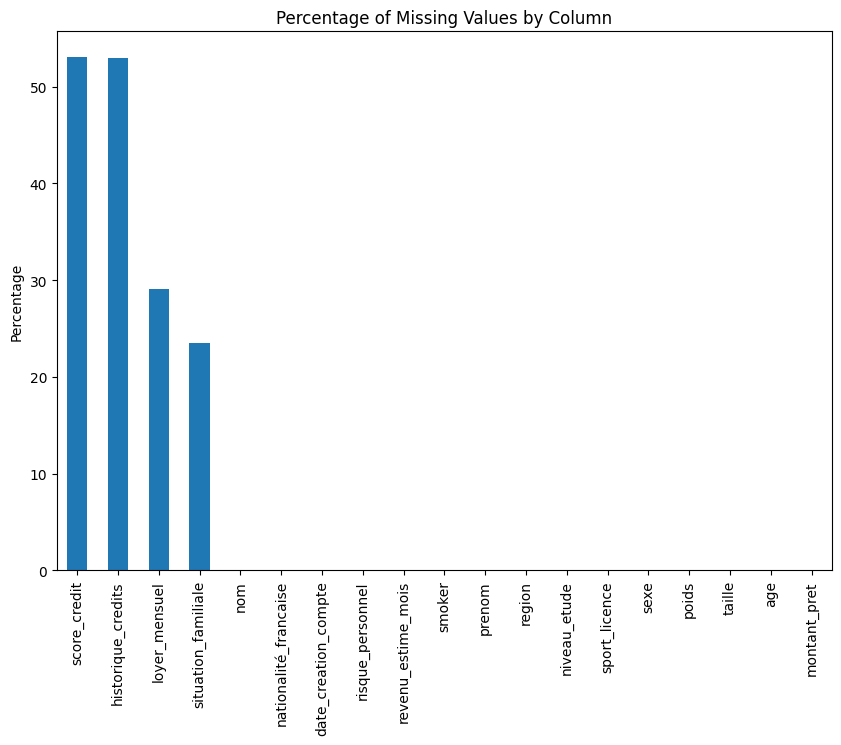

In [4]:
analyse_missing_values(raw_df)

### 3.2 Analyse des outliers

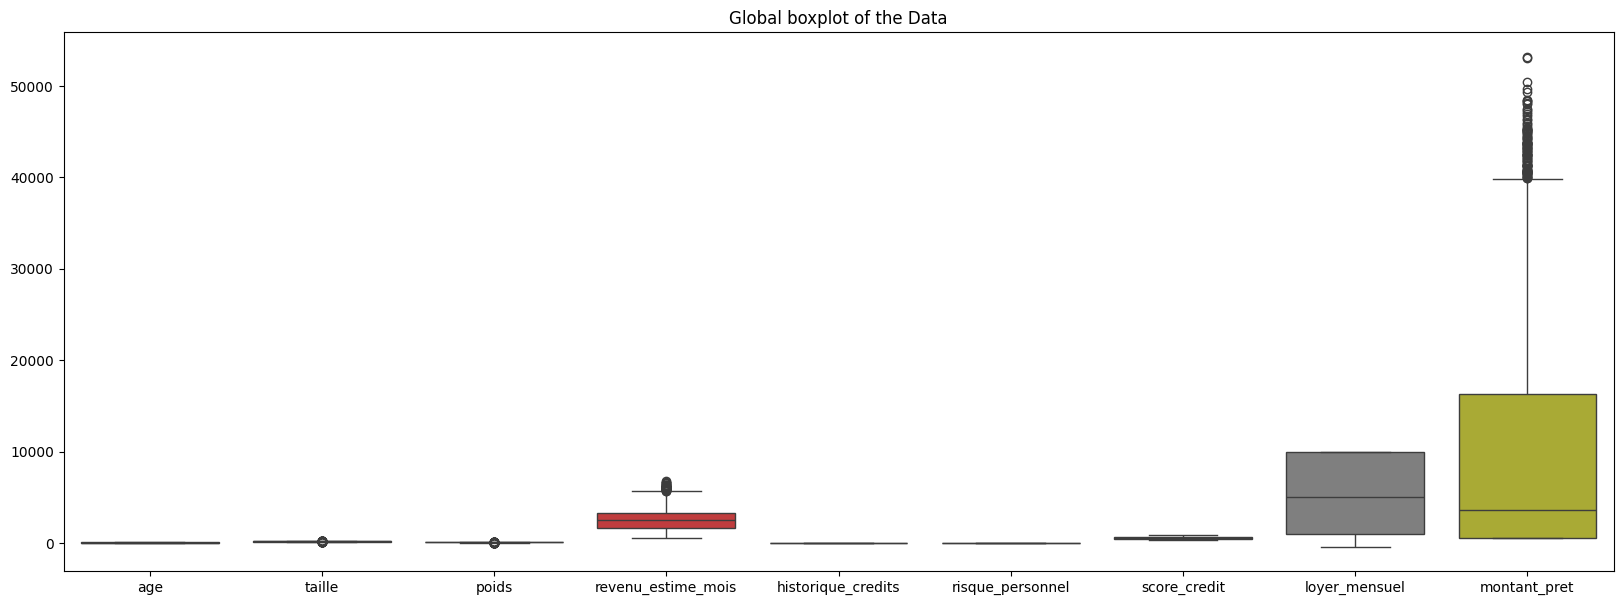

age -> 0 outliers (lower=-11.50, upper=104.50)
taille -> 57 outliers (lower=142.80, upper=197.20)
poids -> 56 outliers (lower=29.05, upper=111.05)
revenu_estime_mois -> 41 outliers (lower=-748.50, upper=5735.50)
historique_credits -> 0 outliers (lower=-3.50, upper=8.50)
risque_personnel -> 0 outliers (lower=-0.53, upper=1.52)
score_credit -> 0 outliers (lower=24.50, upper=1124.50)
loyer_mensuel -> 0 outliers (lower=-12535.58, upper=23521.35)
montant_pret -> 103 outliers (lower=-23118.30, upper=39863.84)


In [5]:
analyse_outliers(raw_df)

### 3.3 Comparaison de variables numeriques

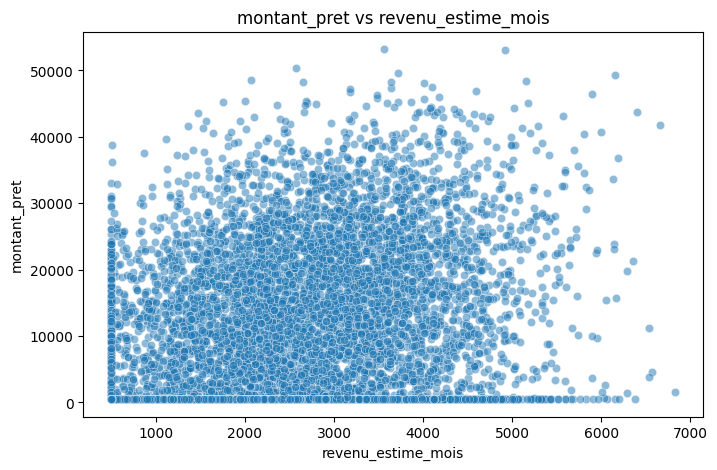

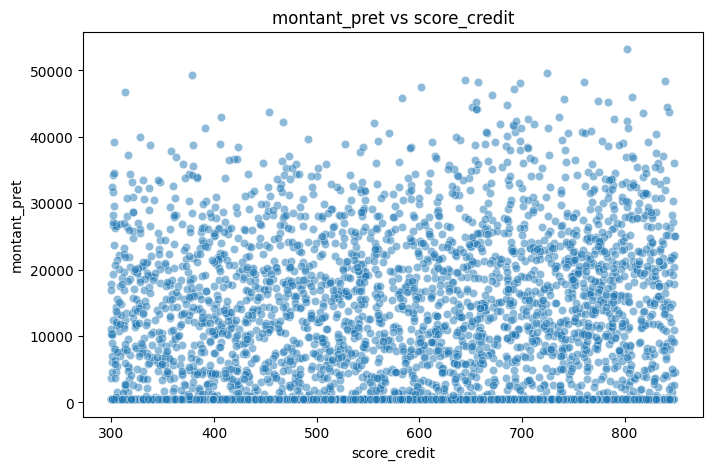

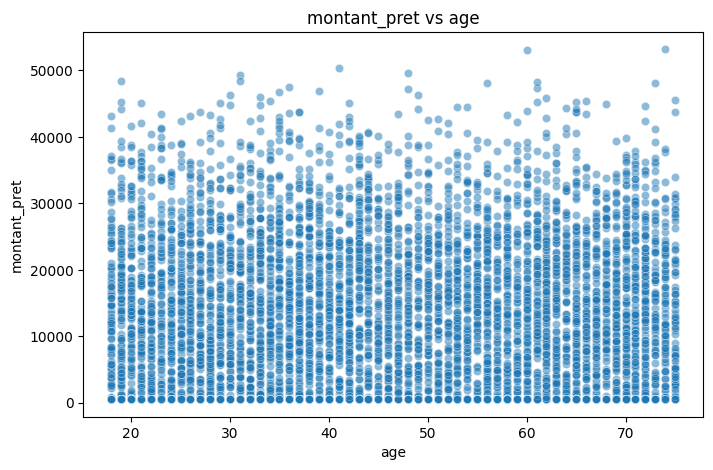

In [6]:
compare_features(raw_df)

### 3.4 Distribution des variables numeriques

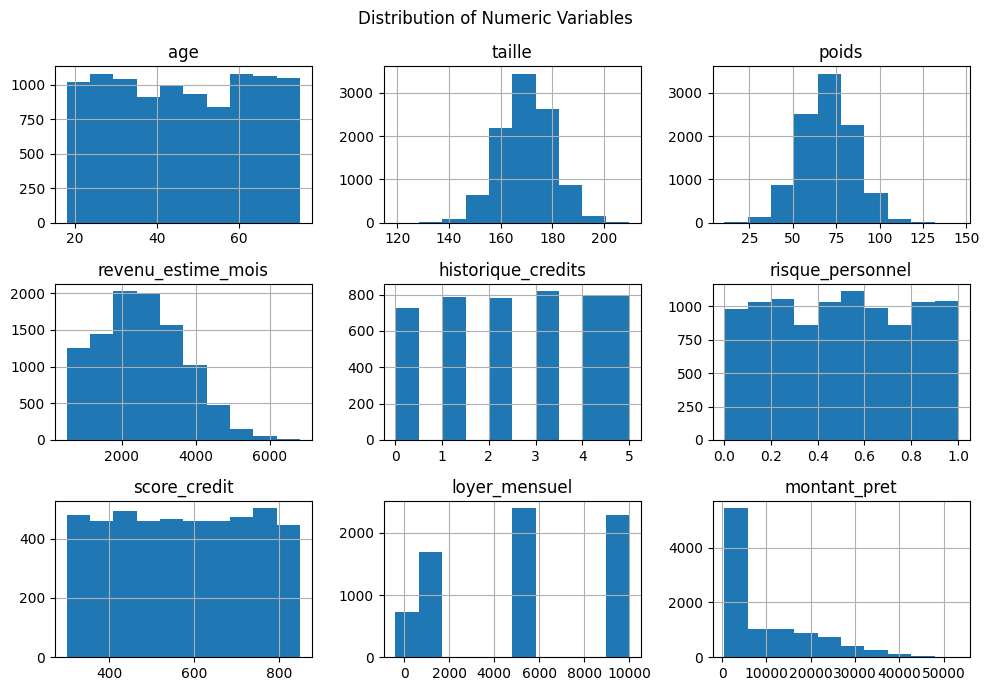

In [7]:
plot_distribution(raw_df)

### 3.5 Correlation entre variables numeriques

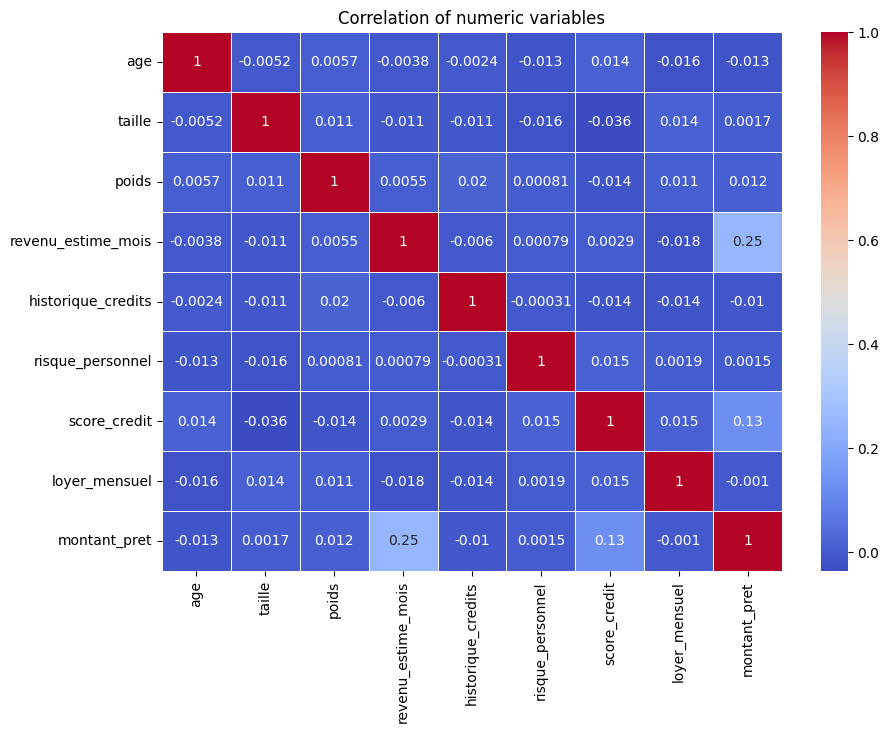

In [8]:
analyse_correlation(raw_df)

## 4. Nettoyage technique

Le pipeline `clean_dataset` applique toutes les etapes de preparation, puis encode les variables textuelles pour obtenir un dataset nettoye entierement numerique.


In [9]:
clean_df = clean_dataset(raw_df)
clean_df.to_csv(CLEAN_PATH, index=False)

print("Shape:", clean_df.shape)
print("NaN restants:", int(clean_df.isna().sum().sum()))
print("Colonnes non numeriques:", clean_df.select_dtypes(exclude="number").columns.tolist())
print()
clean_df.head()

Shape: (9800, 29)
NaN restants: 0
Colonnes non numeriques: []



,nom,prenom,age,taille,poids,sexe,sport_licence,niveau_etude,smoker,nationalité_francaise,revenu_estime_mois,historique_credits,risque_personnel,score_credit,loyer_mensuel,montant_pret,anciennete_compte_jours,region_Auvergne-Rhône-Alpes,region_Bretagne,region_Corse,region_Hauts-de-France,region_Normandie,region_Occitanie,region_Provence-Alpes-Côte d’Azur,region_Île-de-France,situation_familiale_célibataire,situation_familiale_divorcé,situation_familiale_marié,situation_familiale_veuf
0,737,105,73.0,161.1,67.3,1,0,5,0,1,857.0,3.0,0.11,615.0,1377.970,13157.101646,548.0,0,0,0,0,0,1,0,0,1,0,0,0
1,410,506,44.0,168.2,74.9,1,0,1,0,1,5245.0,2.0,0.79,666.8,10000.000,32408.309272,1008.0,0,0,0,0,0,0,0,1,1,0,0,0
2,402,437,71.0,160.3,45.5,1,0,6,1,1,3792.0,0.0,0.13,526.4,5000.000,17975.461375,1021.0,1,0,0,0,0,0,0,0,1,0,0,0
3,614,459,62.0,161.9,87.7,0,1,1,1,1,3291.0,4.0,0.32,572.0,10000.000,16004.737731,808.0,1,0,0,0,0,0,0,0,0,1,0,0
4,921,442,18.0,178.0,77.6,0,1,1,0,1,3893.0,1.0,0.66,541.2,4209.854,10437.682760,1138.0,0,0,1,0,0,0,0,0,1,0,0,0


## 5. Nettoyage ethique

On retire ensuite les colonnes sensibles ou inutilement identifiantes tout en conservant un dataset 100% numerique.


In [10]:
ethical_df = drop_sensitive_columns(clean_df)
ethical_df.to_csv(ETHICAL_PATH, index=False)

print("Shape:", ethical_df.shape)
print("NaN restants:", int(ethical_df.isna().sum().sum()))
print("Colonnes non numeriques:", ethical_df.select_dtypes(exclude="number").columns.tolist())
print()
ethical_df.head()

Shape: (9800, 22)
NaN restants: 0
Colonnes non numeriques: []



,age,sport_licence,niveau_etude,revenu_estime_mois,historique_credits,risque_personnel,score_credit,loyer_mensuel,montant_pret,anciennete_compte_jours,region_Auvergne-Rhône-Alpes,region_Bretagne,region_Corse,region_Hauts-de-France,region_Normandie,region_Occitanie,region_Provence-Alpes-Côte d’Azur,region_Île-de-France,situation_familiale_célibataire,situation_familiale_divorcé,situation_familiale_marié,situation_familiale_veuf
0,73.0,0,5,857.0,3.0,0.11,615.0,1377.970,13157.101646,548.0,0,0,0,0,0,1,0,0,1,0,0,0
1,44.0,0,1,5245.0,2.0,0.79,666.8,10000.000,32408.309272,1008.0,0,0,0,0,0,0,0,1,1,0,0,0
2,71.0,0,6,3792.0,0.0,0.13,526.4,5000.000,17975.461375,1021.0,1,0,0,0,0,0,0,0,1,0,0,0
3,62.0,1,1,3291.0,4.0,0.32,572.0,10000.000,16004.737731,808.0,1,0,0,0,0,0,0,0,0,1,0,0
4,18.0,1,1,3893.0,1.0,0.66,541.2,4209.854,10437.682760,1138.0,0,0,1,0,0,0,0,0,1,0,0,0


## 6. Comparaison finale des sorties

Le projet ne conserve que deux fichiers de sortie, tous les deux numeriques.

In [11]:
comparison = pd.DataFrame(
    {
        "dataset": ["raw", "cleaned", "ethical_cleaned"],
        "rows": [len(raw_df), len(clean_df), len(ethical_df)],
        "columns": [raw_df.shape[1], clean_df.shape[1], ethical_df.shape[1]],
        "missing_values": [
            int(raw_df.isna().sum().sum()),
            int(clean_df.isna().sum().sum()),
            int(ethical_df.isna().sum().sum()),
        ],
        "non_numeric_columns": [
            len(raw_df.select_dtypes(exclude="number").columns),
            len(clean_df.select_dtypes(exclude="number").columns),
            len(ethical_df.select_dtypes(exclude="number").columns),
        ],
    }
)

comparison

,dataset,rows,columns,missing_values,non_numeric_columns
0,raw,10000,19,15857,10
1,cleaned,9800,29,0,0
2,ethical_cleaned,9800,22,0,0


## 7. Conclusion

Le projet livre deux datasets finaux :
- `cleaned.csv` pour un usage technique.
- `ethical_cleaned.csv` sans données sensibles.

Dans les deux cas, les sorties sont directement exploitables par un modele.
